In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import  train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv('mushroom.csv')
df

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,863,sunken,scaly,brown,yes,foul,attached,crowded,narrow,chocolate,...,partial,orange,one,flaring,purple,abundant,leaves,poisonous,5.877891,17.464145
1996,1160,sunken,scaly,purple,yes,musty,attached,distant,narrow,red,...,partial,white,one,zone,yellow,numerous,waste,poisonous,6.500840,13.501957
1997,265,convex,grooves,green,yes,fishy,notched,close,narrow,pink,...,partial,brown,two,evanescent,yellow,abundant,woods,poisonous,13.558064,11.270020
1998,411,bell,smooth,white,no,pungent,free,close,narrow,orange,...,universal,yellow,one,cobwebby,brown,solitary,woods,poisonous,11.092703,8.423199


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 
 14  stalk_co

In [15]:
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [16]:
df.isnull().sum()

,0
Unnamed: 0,0
cap_shape,0
cap_surface,0
cap_color,0
bruises,0
odor,0
gill_attachment,0
gill_spacing,0
gill_size,0
gill_color,0


In [17]:
df.nunique()

,0
Unnamed: 0,976
cap_shape,5
cap_surface,4
cap_color,9
bruises,2
odor,9
gill_attachment,4
gill_spacing,3
gill_size,2
gill_color,12


<Axes: title={'center': 'Class Distribution'}, xlabel='class'>

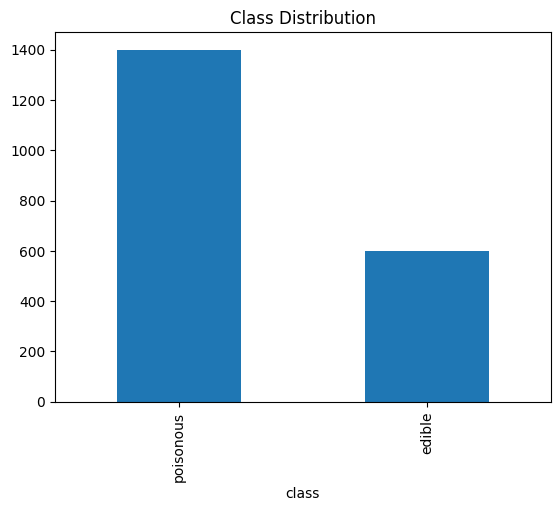

In [18]:
df['class'].value_counts().plot(kind='bar', title='Class Distribution')

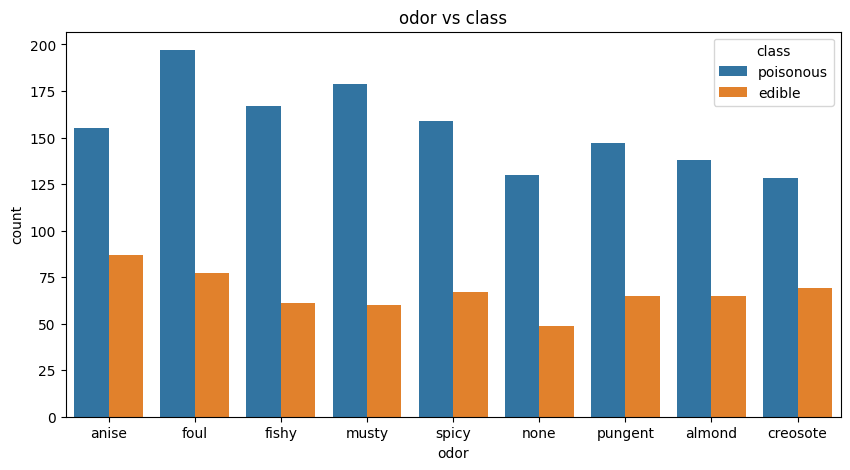

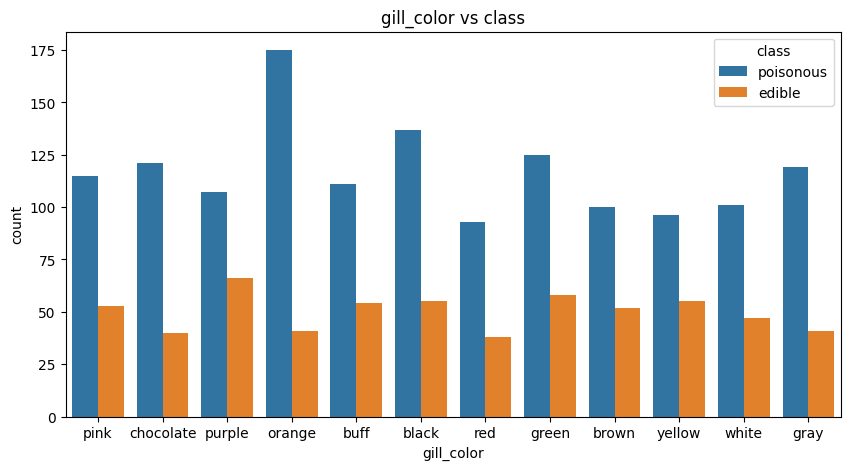

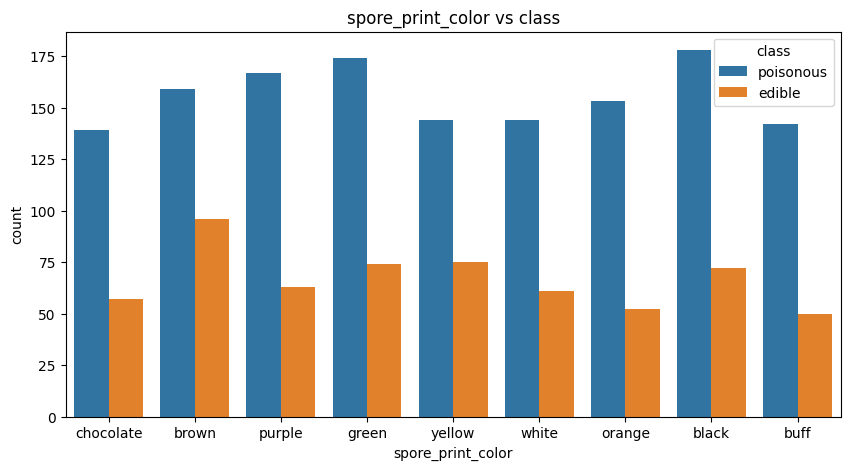

In [19]:
for col in ['odor','gill_color','spore_print_color']:
  plt.figure(figsize=(10,5))
  sns.countplot(x=col,hue='class', data=df)
  plt.title(f'{col} vs class')
  plt.show()

In [20]:
x=df.drop('class',axis=1)
y=df['class']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [21]:
pipe=Pipeline(steps=[('ohe', OneHotEncoder(handle_unknown='ignore')),
                     ('svc', SVC(kernel='rbf'))])
pipe.fit(x_train, y_train)
pipe_pred=pipe.predict(x_test)
print('\nAccuracy:', round(accuracy_score(y_test, pipe_pred), 3))
print('\nClassification report:\n', classification_report(y_test, pipe_pred))


Accuracy: 0.795

Classification report:
               precision    recall  f1-score   support

      edible       0.95      0.33      0.49       120
   poisonous       0.78      0.99      0.87       280

    accuracy                           0.80       400
   macro avg       0.86      0.66      0.68       400
weighted avg       0.83      0.80      0.76       400



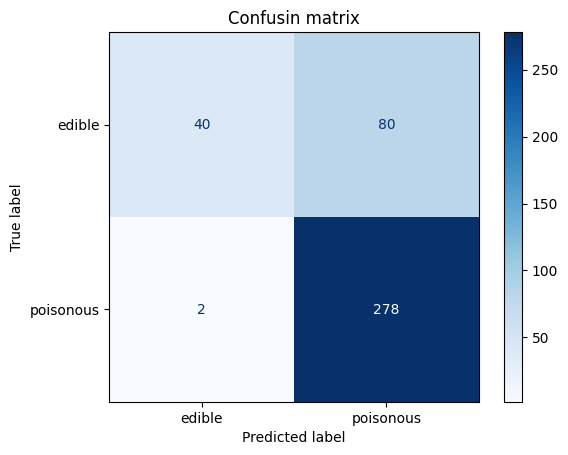

In [22]:
cm=confusion_matrix(y_test,pipe_pred)
ConfusionMatrixDisplay(cm, display_labels=pipe.classes_).plot(cmap='Blues')
plt.title('Confusin matrix')
plt.show()

In [29]:
param_grid={ 'svc__kernel':['linear', 'rbf', 'poly']
             , 'svc__C':[0.1, 1, 10]
             , 'svc__gamma':['scale','auto']
           }
gs=GridSearchCV(pipe,param_grid=param_grid, cv=5,n_jobs=-1, scoring='f1',verbose=1)
gs.fit(x_train, y_train)
print(gs.best_params_)
print(gs.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
{'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
nan


              precision    recall  f1-score   support

      edible       0.96      0.20      0.33       120
   poisonous       0.74      1.00      0.85       280

    accuracy                           0.76       400
   macro avg       0.85      0.60      0.59       400
weighted avg       0.81      0.76      0.70       400



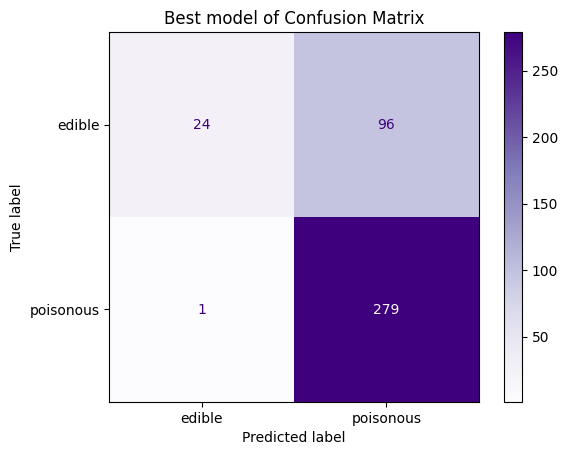

In [36]:
best=gs.best_estimator_
print(classification_report(y_test, best.predict(x_test)))
cm2=confusion_matrix(y_test,best.predict(x_test),labels=best.classes_)
ConfusionMatrixDisplay(cm2,display_labels=best.classes_).plot(cmap='Purples')
plt.title('Best model of Confusion Matrix')
plt.show()


kernel:linear
Acccuracy 0.855
              precision    recall  f1-score   support

      edible       0.87      0.61      0.72       120
   poisonous       0.85      0.96      0.90       280

    accuracy                           0.85       400
   macro avg       0.86      0.78      0.81       400
weighted avg       0.86      0.85      0.85       400


kernel:rbf
Acccuracy 0.795
              precision    recall  f1-score   support

      edible       0.95      0.33      0.49       120
   poisonous       0.78      0.99      0.87       280

    accuracy                           0.80       400
   macro avg       0.86      0.66      0.68       400
weighted avg       0.83      0.80      0.76       400


kernel:poly
Acccuracy 0.8575
              precision    recall  f1-score   support

      edible       0.97      0.54      0.70       120
   poisonous       0.83      0.99      0.91       280

    accuracy                           0.86       400
   macro avg       0.90      0.77      

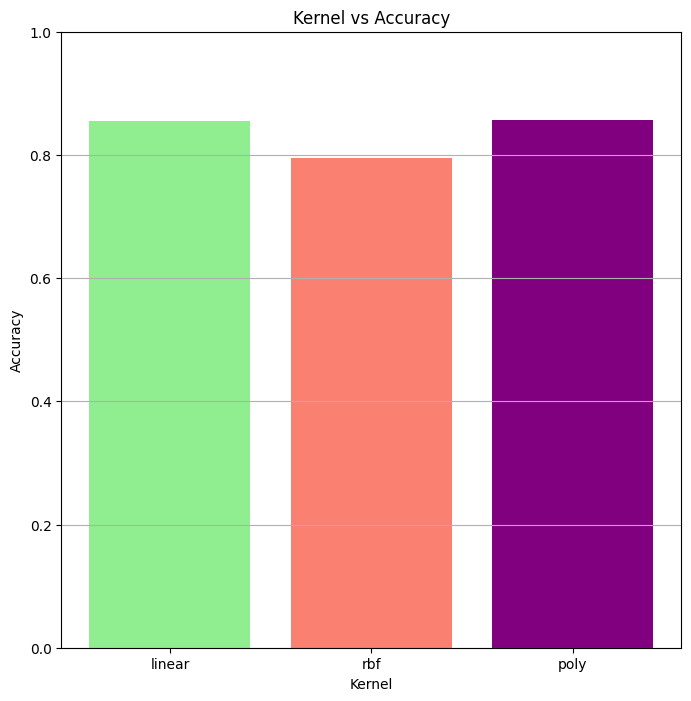

In [49]:
kernels=['linear','rbf','poly']
results={}
for kernel in kernels:
  pipe=Pipeline(steps=[('ohe',OneHotEncoder(handle_unknown='ignore')),
                        ('svc',SVC(kernel=kernel))])
  pipe.fit(x_train, y_train)
  y_preds=pipe.predict(x_test)
  acc=accuracy_score(y_test,y_preds)
  results[kernel]=acc
  print(f"\nkernel:{kernel}")
  print("Acccuracy",round(acc,4))
  print(classification_report(y_test,y_preds))

plt.figure(figsize=(8,8))
plt.bar(results.keys(),results.values(),color=['lightgreen','salmon','Purple'])
plt.xlabel('Kernel')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.title('Kernel vs Accuracy')
plt.grid(axis='y')
plt.show()